# 1. Data Loading and Cleaning

In [4]:
# 01_data_loading_and_cleaning.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load data
df = pd.read_csv('/content/buenos-aires-real-estate-1.csv')

# Extract neighborhood from 'place_with_parent_names'
def extract_neighborhood(s):
    if pd.isna(s) or not isinstance(s, str):
        return np.nan
    parts = [part.strip() for part in s.split('|') if part.strip()]
    if parts:
        return parts[-1]
    return np.nan

df['neighborhood'] = df['place_with_parent_names'].apply(extract_neighborhood)

# Drop columns that are not useful or are redundant after extraction
df = df.drop(columns=['place_with_parent_names', 'properati_url', 'currency'], errors='ignore')

# Handle 'lat-lon' column: split into latitude and longitude
df[['latitude', 'longitude']] = df['lat-lon'].str.split(',', expand=True)
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
df = df.drop(columns=['lat-lon'])

# --- Missing Value Handling --- #

# Impute missing categorical features with 'Unknown' BEFORE dropping any rows based on target
for col in ['neighborhood', 'property_type', 'operation']:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

# Handle missing values for the target variable: drop rows where 'price_aprox_usd' is NaN
df_clean = df.dropna(subset=['price_aprox_usd'])

# Impute missing numerical features with their median (only on df_clean)
for col in ['surface_total_in_m2', 'surface_covered_in_m2', 'price_usd_per_m2', 'price_per_m2',
            'floor', 'rooms', 'expenses', 'latitude', 'longitude']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Remove duplicates
df_clean = df_clean.drop_duplicates()

# Initial exploration (using df_clean for updated overview)
print("=== DATASET OVERVIEW ===")
print(f"Shape: {df_clean.shape}")
print(f"\nColumns: {df_clean.columns.tolist()}")
print(f"\nData types:")
print(df_clean.dtypes)

# Check missing values after cleaning
print("\n=== MISSING VALUES (after cleaning) ===")
print(df_clean.isnull().sum())

# Summary statistics (using df_clean)
print("\n=== SUMMARY STATISTICS (after cleaning) ===")
print(df_clean.describe())


# Ensure the data directory exists within the current working directory
os.makedirs('data', exist_ok=True)

# Save cleaned data to the 'data' directory
df_clean.to_csv('data/buenos-aires-properties-clean.csv', index=False)

print(f"\n Cleaned shape: {df_clean.shape}")

/tmp/ipykernel_1146/311452924.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[col] = df_clean[col].fillna(df_clean[col].median())


=== DATASET OVERVIEW ===
Shape: (7501, 15)

Columns: ['operation', 'property_type', 'price', 'price_aprox_local_currency', 'price_aprox_usd', 'surface_total_in_m2', 'surface_covered_in_m2', 'price_usd_per_m2', 'price_per_m2', 'floor', 'rooms', 'expenses', 'neighborhood', 'latitude', 'longitude']

Data types:
operation                      object
property_type                  object
price                         float64
price_aprox_local_currency    float64
price_aprox_usd               float64
surface_total_in_m2           float64
surface_covered_in_m2         float64
price_usd_per_m2              float64
price_per_m2                  float64
floor                         float64
rooms                         float64
expenses                      float64
neighborhood                   object
latitude                      float64
longitude                     float64
dtype: object

=== MISSING VALUES (after cleaning) ===
operation                     0
property_type                 0
p

#2.Exploratory Data Analysis

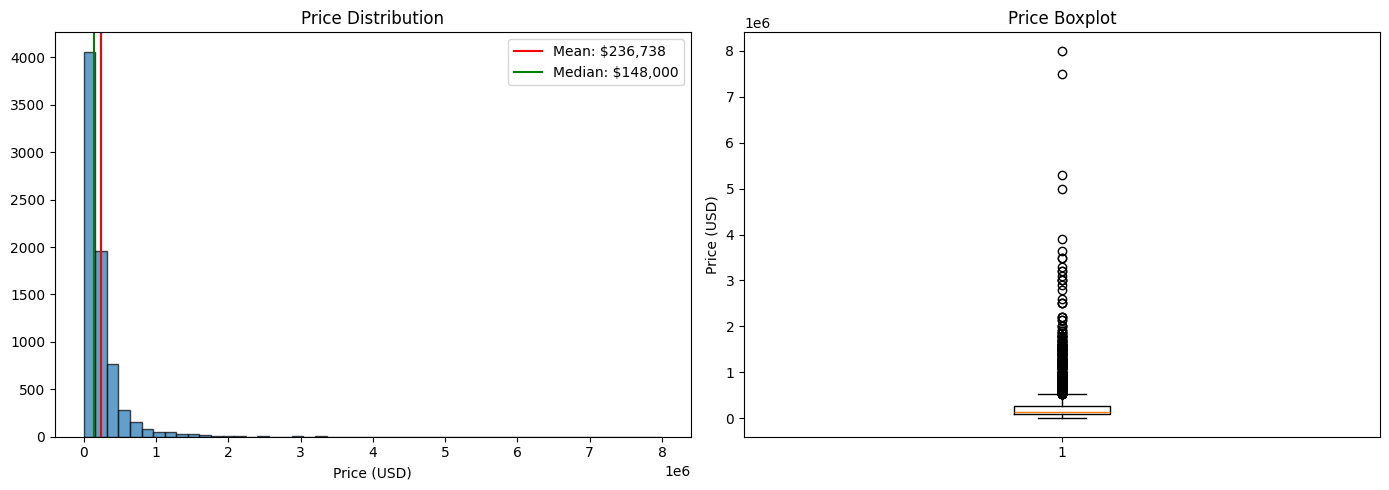

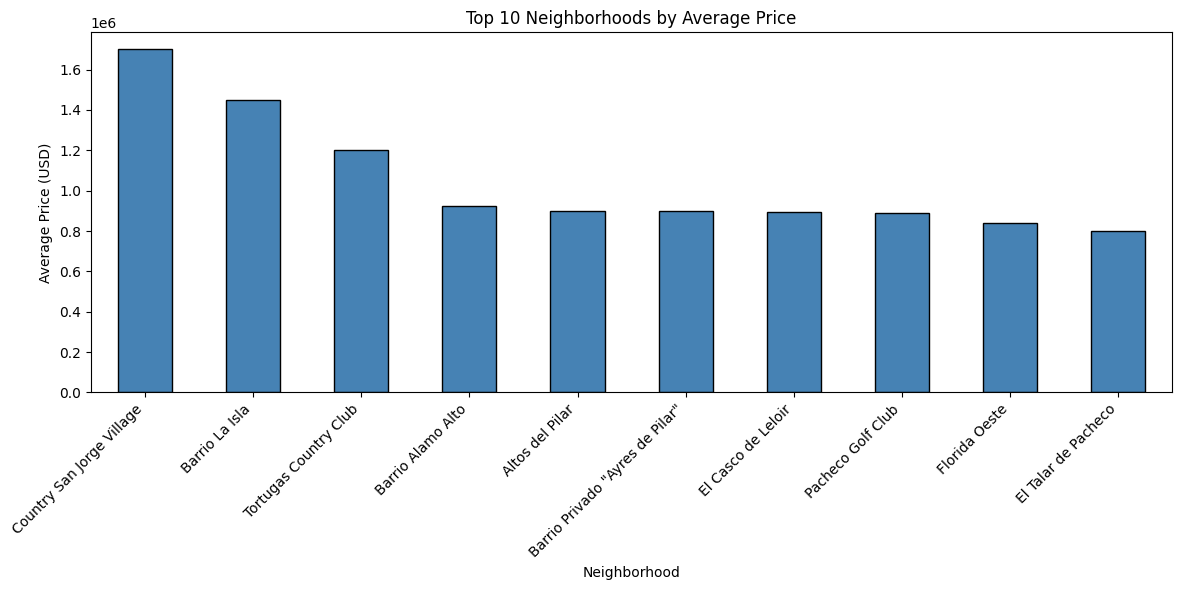

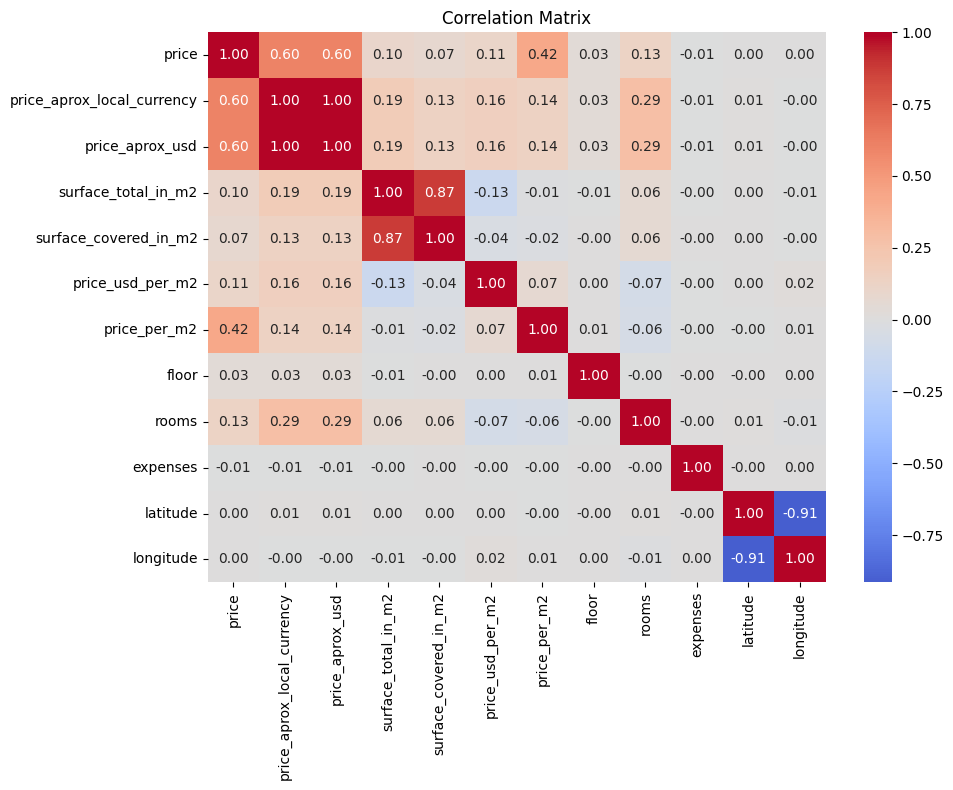


=== KEY INSIGHTS ===
1. Price range: $0 - $8,000,000
2. Mean price: $236,738
3. Median price: $148,000
4. Skew: Right-skewed
5. Most expensive neighborhood: Country San Jorge Village ($1,700,000)
6. Cheapest neighborhood: Don Orione ($23,019)


In [5]:
# 02_exploratory_data_analysis.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os # Import os for directory creation

# Load cleaned data from the 'data' directory
df = pd.read_csv('data/buenos-aires-properties-clean.csv')

# 1. Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['price_aprox_usd'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df['price_aprox_usd'].mean(), color='red',
                label=f'Mean: ${df["price_aprox_usd"].mean():,.0f}')
axes[0].axvline(df['price_aprox_usd'].median(), color='green',
                label=f'Median: ${df["price_aprox_usd"].median():,.0f}')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price (USD)')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['price_aprox_usd'])
axes[1].set_title('Price Boxplot')
axes[1].set_ylabel('Price (USD)')

plt.tight_layout()
# Ensure the results/figures directory exists
os.makedirs('results/figures', exist_ok=True)
plt.savefig('results/figures/price_distribution.png')
plt.show()

# 2. Price by Neighborhood
fig, ax = plt.subplots(figsize=(12, 6))
neighborhood_means = df.groupby('neighborhood')['price_aprox_usd'].mean().sort_values(ascending=False)
neighborhood_means.head(10).plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Top 10 Neighborhoods by Average Price')
ax.set_xlabel('Neighborhood')
ax.set_ylabel('Average Price (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('results/figures/neighborhood_prices.png')
plt.show()

# 3. Correlation matrix
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.savefig('results/figures/correlation_matrix.png')
plt.show()

# 4. Key insights
print("\n=== KEY INSIGHTS ===")
print(f"1. Price range: ${df['price_aprox_usd'].min():,.0f} - ${df['price_aprox_usd'].max():,.0f}")
print(f"2. Mean price: ${df['price_aprox_usd'].mean():,.0f}")
print(f"3. Median price: ${df['price_aprox_usd'].median():,.0f}")
print(f"4. Skew: {'Right-skewed' if df['price_aprox_usd'].mean() > df['price_aprox_usd'].median() else 'Left-skewed'}")
print(f"5. Most expensive neighborhood: {neighborhood_means.index[0]} (${neighborhood_means.iloc[0]:,.0f})")
print(f"6. Cheapest neighborhood: {neighborhood_means.index[-1]} (${neighborhood_means.iloc[-1]:,.0f})")

#3.Feature Engineering

In [12]:
# 03_feature_engineering.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load cleaned data
df = pd.read_csv('./data/buenos-aires-properties-clean.csv')

# 1. Create new features
df['price_per_m2'] = df['price_aprox_usd'] / df['surface_covered_in_m2']

# 2. One-hot encoding for categorical variables
df_encoded = pd.get_dummies(df, columns=['neighborhood', 'property_type', 'operation'], prefix=['neighborhood', 'property_type', 'operation'], dtype=int)

# Drop original 'price' and 'price_aprox_local_currency' as they are highly correlated/redundant with 'price_aprox_usd'
df_encoded = df_encoded.drop(columns=['price', 'price_aprox_local_currency'], errors='ignore')

# 3. Check the result
print(f"Original shape: {df.shape}")
print(f"Encoded shape: {df_encoded.shape}")
print(f"\nNew columns: {df_encoded.columns.tolist()}")

# 4. Save encoded data
os.makedirs('./data', exist_ok=True)
df_encoded.to_csv('./data/buenos-aires-properties-encoded.csv', index=False)

# 5. Feature selection
target = 'price_aprox_usd'
# Select only numerical features for correlation calculation and model training
features = [col for col in df_encoded.select_dtypes(include=np.number).columns if col != target]

print(f"\nFeatures: {len(features)}")
print(f"Target: {target}")

# 6. Check correlation with target
correlations = df_encoded[features + [target]].corr()[target].sort_values(ascending=False)
print("\n=== TOP FEATURES BY CORRELATION ===")
print(correlations.head(10))

Original shape: (7501, 15)
Encoded shape: (7501, 343)

New columns: ['price_aprox_usd', 'surface_total_in_m2', 'surface_covered_in_m2', 'price_usd_per_m2', 'price_per_m2', 'floor', 'rooms', 'expenses', 'latitude', 'longitude', 'neighborhood_Abasto', 'neighborhood_Acacias Blancas', 'neighborhood_Acassuso', 'neighborhood_Adrogué', 'neighborhood_Aeropuerto Internacional Ezeiza', 'neighborhood_Agronomía', 'neighborhood_Aldo Bonzi', 'neighborhood_Alejandro Korn', 'neighborhood_Alejandro Petión', 'neighborhood_Almagro', 'neighborhood_Altamira', 'neighborhood_Altos del Pilar', 'neighborhood_Avellaneda', 'neighborhood_Balvanera', 'neighborhood_Banfield', 'neighborhood_Barracas', 'neighborhood_Barrio Alamo Alto', 'neighborhood_Barrio Cerrado "Boulevares"', 'neighborhood_Barrio Cerrado "Champagnat"', 'neighborhood_Barrio Cerrado "El Aromo"', 'neighborhood_Barrio Cerrado "Isla del Sol"', 'neighborhood_Barrio Cerrado "La Candela"', 'neighborhood_Barrio Cerrado "La Cautiva del Pilar"', 'neighborhoo

#4.Model Training

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os
import pickle

# Load encoded data
df = pd.read_csv('./data/buenos-aires-properties-encoded.csv')

# 1. Prepare features and target
target = 'price_aprox_usd'
# Explicitly select only numeric columns, excluding the target
numeric_cols = df.select_dtypes(include=np.number).columns
features = [col for col in numeric_cols if col != target]

X = df[features]
y = df[target]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# --- FIX START: Handle infinite values before scaling ---
# Replace infinite values with NaN
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

# Impute any remaining NaNs (if any) with the median of their columns
# This is crucial if some infinities were introduced by price_per_m2 division by zero for example
for col in X_train.columns:
    if X_train[col].isnull().any():
        median_val = X_train[col].median()
        # Correct way to assign with fillna to avoid FutureWarning
        X_train.loc[:, col] = X_train[col].fillna(median_val)
        X_test.loc[:, col] = X_test[col].fillna(median_val) # Use training median for test set
# --- FIX END ---

# 3. Scale features (optional)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 5. Make predictions
y_pred = model.predict(X_test_scaled)

# 6. Evaluate
print("\n=== MODEL PERFORMANCE ===")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred)):,.2f}")
print(f"MAE: ${mean_absolute_error(y_test, y_pred):,.2f}")

# 7. Feature importance (coefficients)
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print("\n=== TOP 10 FEATURE COEFFICIENTS ===")
print(coef_df.head(10))

# 8. Save model and results
os.makedirs('./results', exist_ok=True)
with open('./results/model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('./results/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("\n Model and scaler saved!")

X shape: (7501, 342)
y shape: (7501,)

Training set: 6000 samples
Test set: 1501 samples

=== MODEL PERFORMANCE ===
R² Score: 0.2250
RMSE: $304,404.85
MAE: $124,371.02

=== TOP 10 FEATURE COEFFICIENTS ===
                        Feature    Coefficient
0           surface_total_in_m2  122444.669575
5                         rooms   62550.141584
3                  price_per_m2   58647.462092
2              price_usd_per_m2   51399.954945
11        neighborhood_Acassuso   37563.061735
340         property_type_store   36998.452035
228       neighborhood_Nordelta   36776.111873
339         property_type_house   36668.036888
252  neighborhood_Puerto Madero   30473.790193
214       neighborhood_Martínez   26143.304490

 Model and scaler saved!


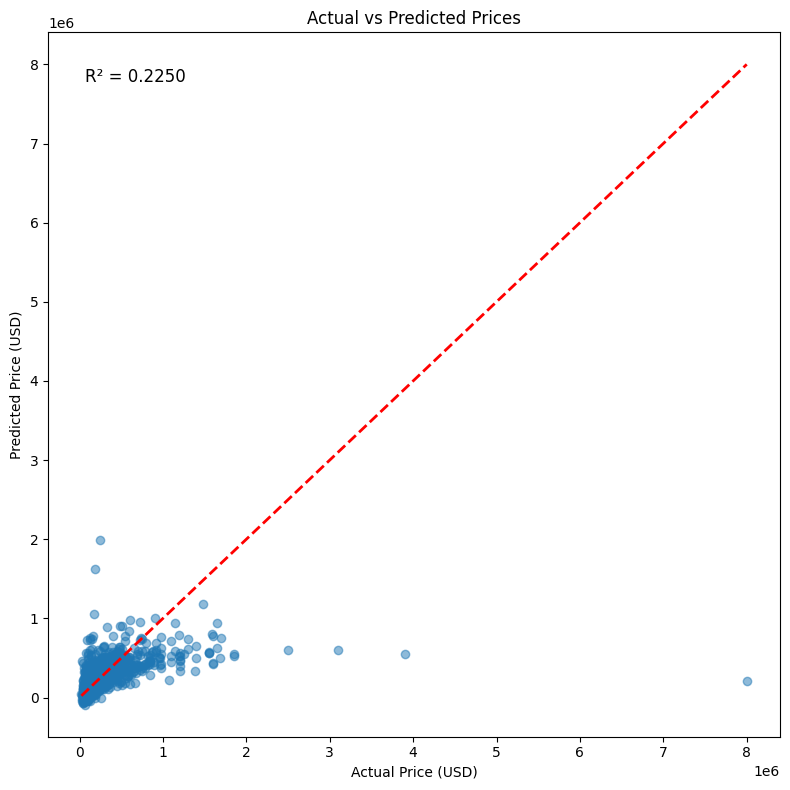

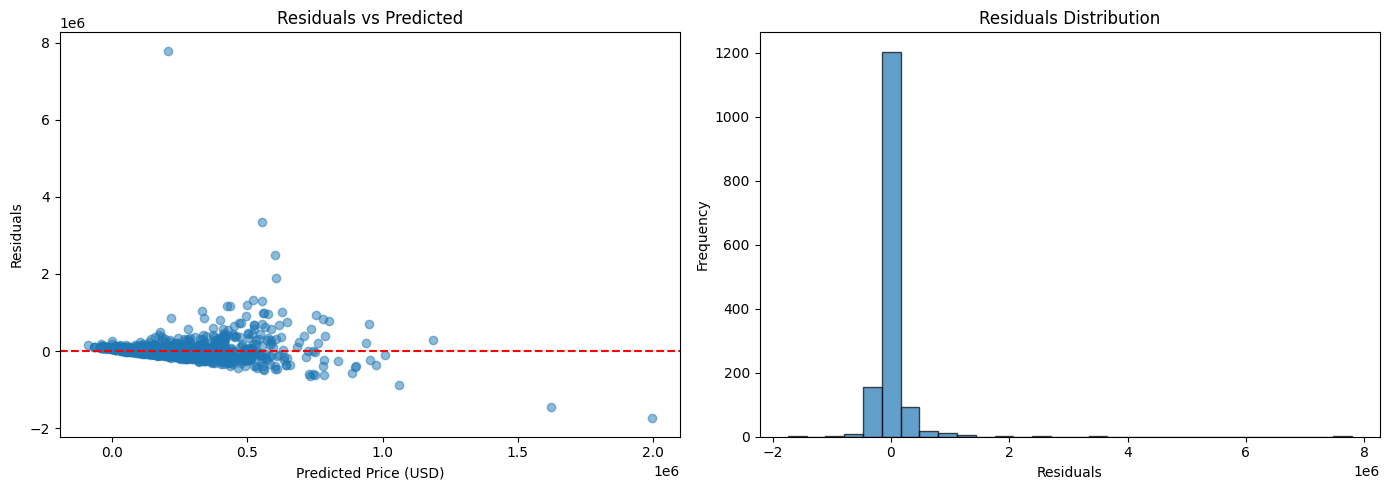

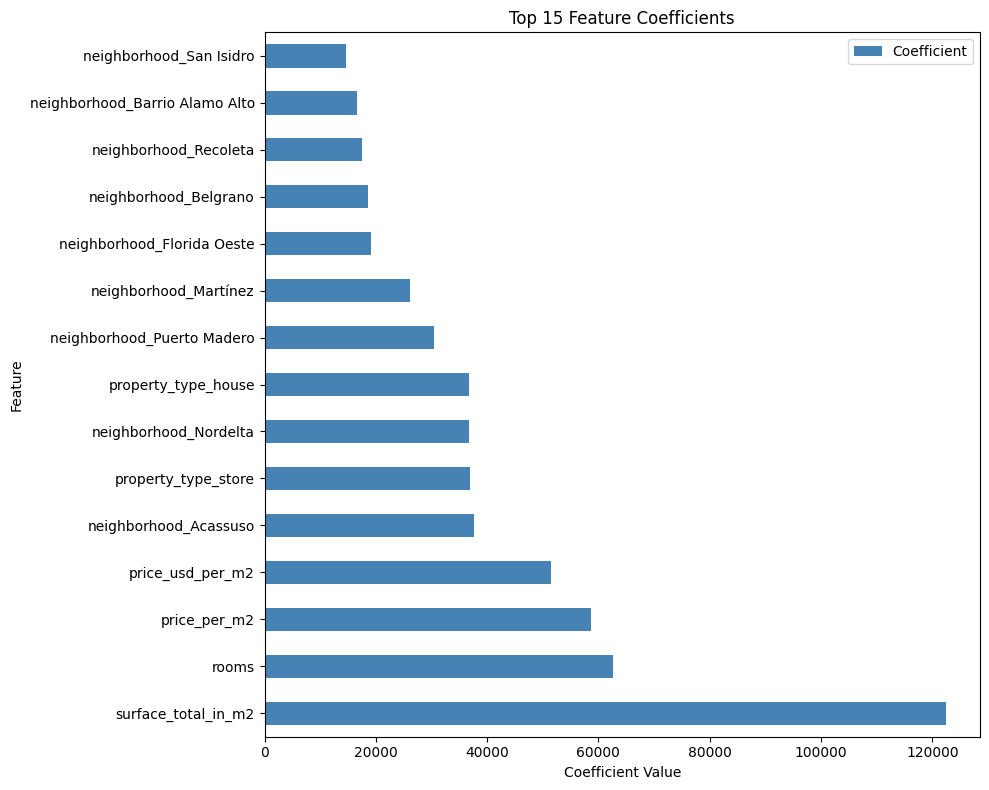

=== MODEL METRICS ===
R² Score: 0.2250
MSE: $92,662,315,253.04
RMSE: $304,404.85
MAE: $124,371.02
MAPE: 64.55%


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pickle
import os

# Ensure results/figures directory exists
os.makedirs('./results/figures', exist_ok=True)

# Load model and scaler
with open('./results/model.pkl', 'rb') as f:
    model = pickle.load(f)
with open('./results/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Load data
df = pd.read_csv('./data/buenos-aires-properties-encoded.csv')

# Prepare features and target
target = 'price_aprox_usd'
# Explicitly select only numeric columns, excluding the target
numeric_cols = df.select_dtypes(include=np.number).columns
features = [col for col in numeric_cols if col != target]

X = df[features]
y = df[target]

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- FIX START: Handle infinite values before scaling (replicated from training) ---
# Replace infinite values with NaN
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

# Impute any remaining NaNs (if any) with the median of their columns
for col in X_train.columns:
    if X_train[col].isnull().any():
        median_val = X_train[col].median()
        # Correct way to assign with fillna to avoid FutureWarning
        X_train.loc[:, col] = X_train[col].fillna(median_val)
        X_test.loc[:, col] = X_test[col].fillna(median_val) # Use training median for test set
# --- FIX END ---

# Scale
X_test_scaled = scaler.transform(X_test)

# Predict
y_pred = model.predict(X_test_scaled)

# 1. Actual vs Predicted
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred, alpha=0.5)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax.set_xlabel('Actual Price (USD)')
ax.set_ylabel('Predicted Price (USD)')
ax.set_title('Actual vs Predicted Prices')

# Add R² score
ax.text(0.05, 0.95, f'R² = {r2_score(y_test, y_pred):.4f}',
        transform=ax.transAxes, fontsize=12, verticalalignment='top')

plt.tight_layout()
plt.savefig('./results/figures/actual_vs_predicted.png')
plt.show()

# 2. Residuals
residuals = y_test - y_pred

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
ax1.scatter(y_pred, residuals, alpha=0.5)
ax1.axhline(y=0, color='red', linestyle='--')
ax1.set_xlabel('Predicted Price (USD)')
ax1.set_ylabel('Residuals')
ax1.set_title('Residuals vs Predicted')

# Residuals histogram
ax2.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
ax2.set_xlabel('Residuals')
ax2.set_ylabel('Frequency')
ax2.set_title('Residuals Distribution')

plt.tight_layout()
plt.savefig('./results/figures/residual_plot.png')
plt.show()

# 3. Feature Importance
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
coef_df.head(15).plot(kind='barh', x='Feature', y='Coefficient', ax=ax, color='steelblue')
ax.set_title('Top 15 Feature Coefficients')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('./results/figures/feature_importance.png')
plt.show()

# 4. Model Metrics
print("=== MODEL METRICS ===")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: ${mean_squared_error(y_test, y_pred):,.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred)):,.2f}")
print(f"MAE: ${mean_absolute_error(y_test, y_pred):,.2f}")
print(f"MAPE: {np.mean(np.abs((y_test - y_pred) / y_test)) * 100:.2f}%")

# 5. Save metrics
os.makedirs('./results', exist_ok=True)
with open('./results/model_metrics.txt', 'w') as f:
    f.write("=== MODEL PERFORMANCE METRICS ===\n")
    f.write(f"R² Score: {r2_score(y_test, y_pred):.4f}\n")
    f.write(f"MSE: ${mean_squared_error(y_test, y_pred):,.2f}\n")
    f.write(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred)):,.2f}\n")
    f.write(f"MAE: ${mean_absolute_error(y_test, y_pred):,.2f}\n")
    f.write(f"MAPE: {np.mean(np.abs((y_test - y_pred) / y_test)) * 100:.2f}%\n")

#5.Model Evaluation

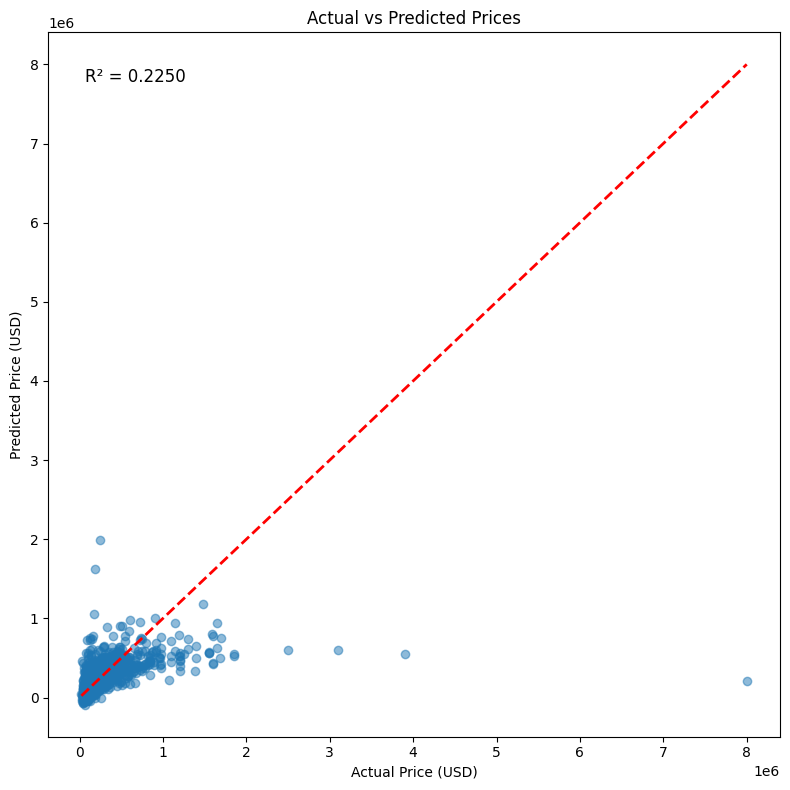

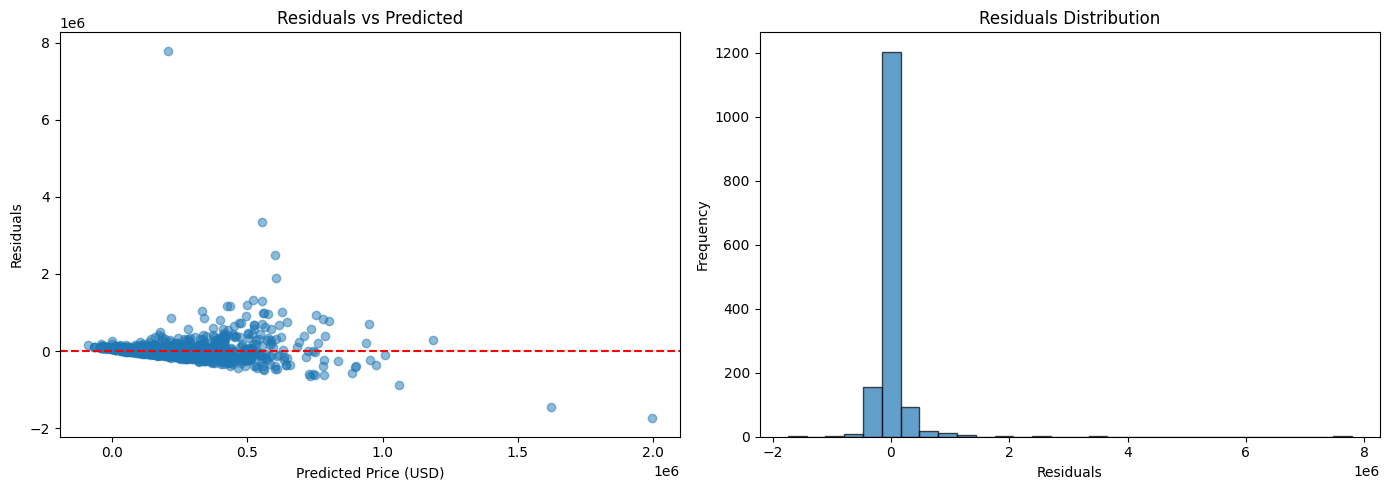

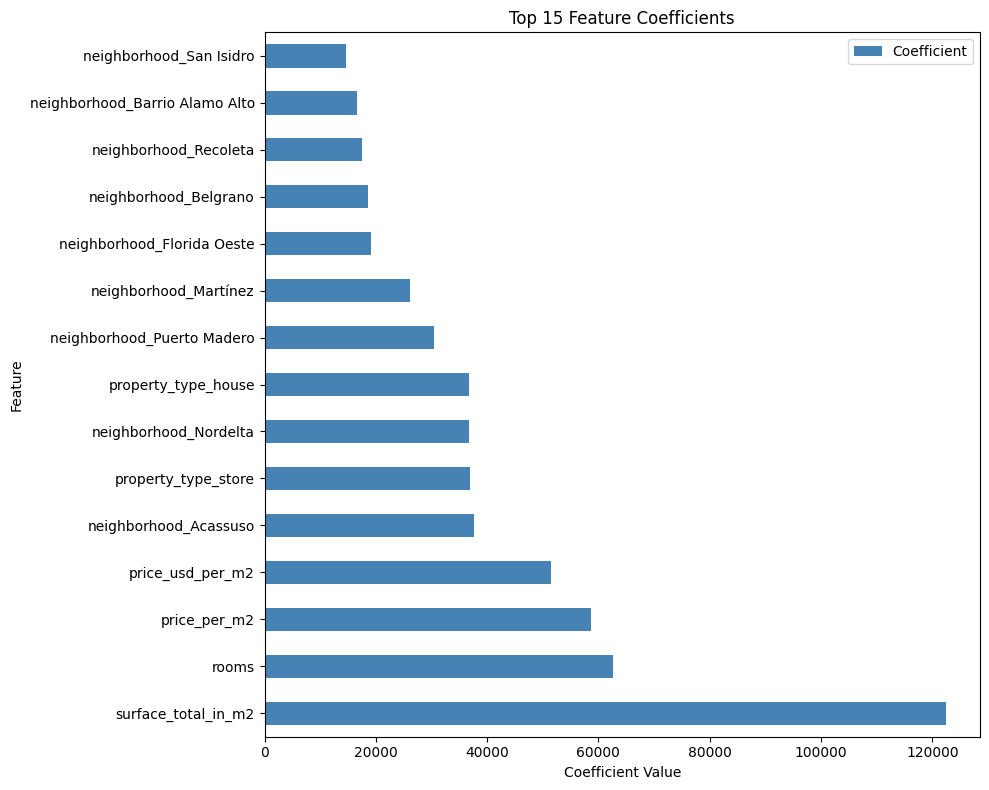

=== MODEL METRICS ===
R² Score: 0.2250
MSE: $92,662,315,253.04
RMSE: $304,404.85
MAE: $124,371.02
MAPE: 64.55%


In [21]:
# 05_model_evaluation.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pickle
import os

# Ensure results/figures directory exists
os.makedirs('./results/figures', exist_ok=True)

# Load model and scaler
with open('./results/model.pkl', 'rb') as f:
    model = pickle.load(f)
with open('./results/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Load data
df = pd.read_csv('./data/buenos-aires-properties-encoded.csv')

# Prepare features and target
target = 'price_aprox_usd'
# Explicitly select only numeric columns, excluding the target
numeric_cols = df.select_dtypes(include=np.number).columns
features = [col for col in numeric_cols if col != target]

X = df[features]
y = df[target]

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- FIX START: Handle infinite values before scaling (replicated from training) ---
# Replace infinite values with NaN
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

# Impute any remaining NaNs (if any) with the median of their columns
for col in X_train.columns:
    if X_train[col].isnull().any():
        median_val = X_train[col].median()
        # Correct way to assign with fillna to avoid FutureWarning
        X_train.loc[:, col] = X_train[col].fillna(median_val)
        X_test.loc[:, col] = X_test[col].fillna(median_val) # Use training median for test set
# --- FIX END ---

# Scale
X_test_scaled = scaler.transform(X_test)

# Predict
y_pred = model.predict(X_test_scaled)

# 1. Actual vs Predicted
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred, alpha=0.5)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax.set_xlabel('Actual Price (USD)')
ax.set_ylabel('Predicted Price (USD)')
ax.set_title('Actual vs Predicted Prices')

# Add R² score
ax.text(0.05, 0.95, f'R² = {r2_score(y_test, y_pred):.4f}',
        transform=ax.transAxes, fontsize=12, verticalalignment='top')

plt.tight_layout()
plt.savefig('./results/figures/actual_vs_predicted.png')
plt.show()

# 2. Residuals
residuals = y_test - y_pred

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
ax1.scatter(y_pred, residuals, alpha=0.5)
ax1.axhline(y=0, color='red', linestyle='--')
ax1.set_xlabel('Predicted Price (USD)')
ax1.set_ylabel('Residuals')
ax1.set_title('Residuals vs Predicted')

# Residuals histogram
ax2.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
ax2.set_xlabel('Residuals')
ax2.set_ylabel('Frequency')
ax2.set_title('Residuals Distribution')

plt.tight_layout()
plt.savefig('./results/figures/residual_plot.png')
plt.show()

# 3. Feature Importance
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
coef_df.head(15).plot(kind='barh', x='Feature', y='Coefficient', ax=ax, color='steelblue')
ax.set_title('Top 15 Feature Coefficients')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('./results/figures/feature_importance.png')
plt.show()

# 4. Model Metrics
print("=== MODEL METRICS ===")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: ${mean_squared_error(y_test, y_pred):,.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred)):,.2f}")
print(f"MAE: ${mean_absolute_error(y_test, y_pred):,.2f}")
print(f"MAPE: {np.mean(np.abs((y_test - y_pred) / y_test)) * 100:.2f}%")

# 5. Save metrics
os.makedirs('./results', exist_ok=True)
with open('./results/model_metrics.txt', 'w') as f:
    f.write("=== MODEL PERFORMANCE METRICS ===\n")
    f.write(f"R² Score: {r2_score(y_test, y_pred):.4f}\n")
    f.write(f"MSE: ${mean_squared_error(y_test, y_pred):,.2f}\n")
    f.write(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred)):,.2f}\n")
    f.write(f"MAE: ${mean_absolute_error(y_test, y_pred):,.2f}\n")
    f.write(f"MAPE: {np.mean(np.abs((y_test - y_pred) / y_test)) * 100:.2f}%\n")

# 2.2. Linear Regression: Your First Predictive Model


In [25]:
# ============================================
# 2.2 Linear Regression: Complete Code
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load data
df = pd.read_csv("/content/buenos-aires-real-estate-1.csv")

# Ensure target variable has no NaNs BEFORE creating X and y
df.dropna(subset=["price_aprox_usd"], inplace=True)

# Create features and target
X = df[["surface_covered_in_m2"]]
y = df["price_aprox_usd"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Impute missing values in X_train and X_test
# Use the median from the training set to avoid data leakage
median_surface = X_train['surface_covered_in_m2'].median()
X_train.loc[:, 'surface_covered_in_m2'] = X_train['surface_covered_in_m2'].fillna(median_surface)
X_test.loc[:, 'surface_covered_in_m2'] = X_test['surface_covered_in_m2'].fillna(median_surface)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== MODEL RESULTS ===")
print(f"R²: {r2:.4f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"MAE: ${mae:,.2f}")
print(f"Equation: Price = ${model.coef_[0]:,.2f} × Size + ${model.intercept_:,.2f}")

=== MODEL RESULTS ===
R²: 0.0224
RMSE: $235,893.14
MAE: $151,147.54
Equation: Price = $51.34 × Size + $234,452.68


#2.3 Preventing Overfitting with L1 and L2 Penalties


In [44]:
# ============================================
# 2.3 Preventing Overfitting with L1 and L2 Penalties
# Complete Script
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Removed: from wrangle import clean_files

# ============================================
# 1. Setup and Configuration
# ============================================

plt.style.use('seaborn-v0_8-whitegrid')
# %matplotlib inline  # Uncomment if using Jupyter

def root_mean_squared_error(y_true, y_pred):
    """Calculate Root Mean Squared Error."""
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("=" * 70)
print(" PREVENTING OVERFITTING WITH L1 AND L2 PENALTIES")
print("=" * 70)
print(" Libraries imported successfully!")

# ============================================
# 2. Load and Prepare Data
# ============================================

print("\n" + "=" * 70)
print(" LOADING AND PREPARING DATA")
print("=" * 70)

# Load data: Using the already encoded CSV from previous steps
df = pd.read_csv('./data/buenos-aires-properties-encoded.csv')

# Define target and features
target_col = "price_aprox_usd"
feature_cols = [col for col in df.columns if col != target_col]

# Create explicit copies to avoid SettingWithCopyWarning
X = df[feature_cols].copy()
y = df[target_col].copy()

# Ensure X and y are free of NaNs and Infs (should be from prior cleaning/encoding steps)
X.replace([np.inf, -np.inf], np.nan, inplace=True)
y.replace([np.inf, -np.inf], np.nan, inplace=True)

# Impute any remaining NaNs (if any) with the median of their columns
# This is a safeguard; df_encoded should already be clean.
for col in X.columns:
    if X[col].isnull().any():
        median_val = X[col].median()
        # Correct way to assign with fillna to avoid FutureWarning
        X.loc[:, col] = X[col].fillna(median_val)

y.fillna(y.median(), inplace=True)

print(f" Dataset loaded successfully!")
print(f"   Features shape: {X.shape}")
print(f"   Target shape: {y.shape}")
# print(f"   Feature columns: {feature_cols}") # Too many features to print

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Select 3 features for demonstration (using available features)
# Replaced 'bedrooms' and 'bathrooms' with 'rooms' and 'floor' as they are present in df_encoded
X_train_3 = X_train[["surface_covered_in_m2", "rooms", "floor"]]
X_test_3 = X_test[["surface_covered_in_m2", "rooms", "floor"]]

 PREVENTING OVERFITTING WITH L1 AND L2 PENALTIES
 Libraries imported successfully!

 LOADING AND PREPARING DATA
 Dataset loaded successfully!
   Features shape: (7501, 342)
   Target shape: (7501,)


#2.4 Model Selection

📊 2.4 MODEL SELECTION
✅ Libraries imported successfully!

📊 LOADING AND PREPARING DATA
✅ Data loaded successfully!
   Total samples: 7501
   Features: 342
   X_train_4 shape: (6000, 342)
   X_test_4 shape: (1501, 342)

📊 TRAINING MODELS

📌 1. Training Baseline Model...
   Baseline Train RMSE: $304,953.60
   Baseline Test RMSE: $345,927.58
   ✅ Baseline model trained

📌 2. Training Linear Regression...
   Linear Train RMSE: $239,258.79
   Linear Test RMSE: $304,404.85
   ✅ Linear Regression trained

📌 3. Training Ridge Regression with CV...
   Ridge Train RMSE: $255,045.73
   Ridge Test RMSE: $307,601.76
   Best Ridge alpha: 5722.367659
   ✅ Ridge Regression trained

📌 4. Training Lasso Regression with CV...
   Lasso Train RMSE: $239,266.98
   Lasso Test RMSE: $304,053.89
   Best Lasso alpha: 100.000000
   Non-zero features: 306
   ✅ Lasso Regression trained

📊 MODEL COMPARISON TABLE
                   Train_RMSE  Test_RMSE       Gap  Improvement_%  \
Model                              

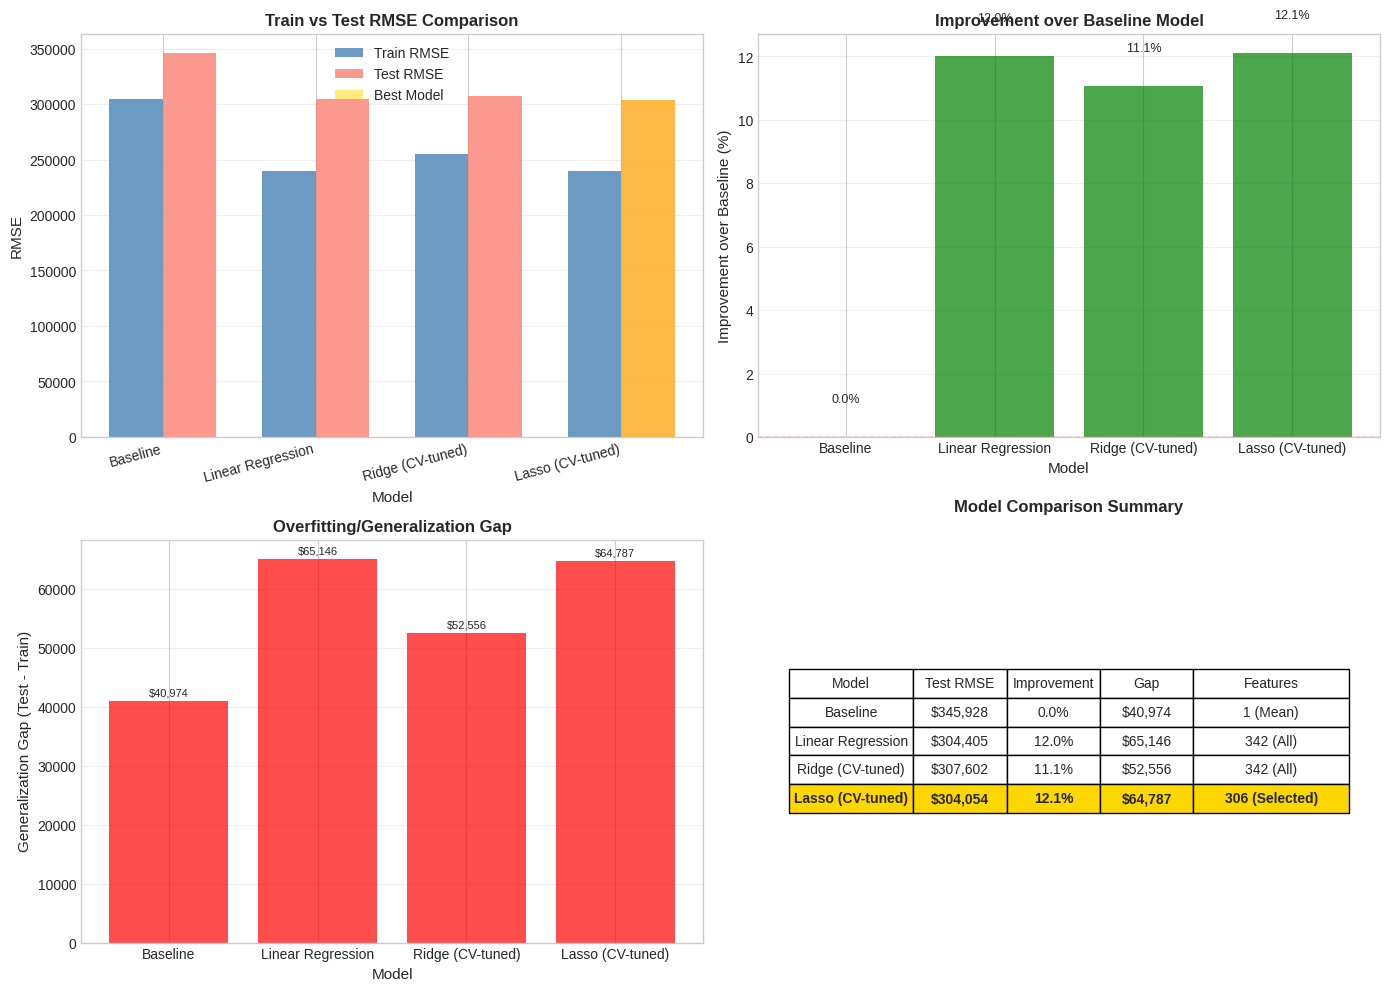

In [43]:
# ============================================
# 2.4 Model Selection - Complete Script
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Removed: from wrangle import clean_files

# ============================================
# 1. Setup and Configuration
# ============================================

plt.style.use('seaborn-v0_8-whitegrid') # Corrected style name

def root_mean_squared_error(y_true, y_pred):
    """Calculate Root Mean Squared Error."""
    return np.sqrt(mean_squared_error(y_true, y_pred))

def get_rmse_4(model, X, y_true):
    """Calculate RMSE for a given model and dataset."""
    y_pred = model.predict(X)
    return root_mean_squared_error(y_true, y_pred)

print("=" * 80)
print("📊 2.4 MODEL SELECTION")
print("=" * 80)
print("✅ Libraries imported successfully!")

# ============================================
# 2. Load and Prepare Data
# ============================================

print("\n" + "=" * 80)
print("📊 LOADING AND PREPARING DATA")
print("=" * 80)

# Load data: Using the already encoded CSV from previous steps
df = pd.read_csv('./data/buenos-aires-properties-encoded.csv')

# Define target and features
target = "price_aprox_usd"
features = [col for col in df.columns if col != target]

X = df[features]
y = df[target]

# Split data
X_train_4, X_test_4, y_train_4, y_test_4 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- FIX START: Handle infinite values before scaling ---
# Replace infinite values with NaN
X_train_4.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test_4.replace([np.inf, -np.inf], np.nan, inplace=True)

# Impute any remaining NaNs (if any) with the median of their columns
# This is crucial if some infinities were introduced by price_per_m2 division by zero for example
for col in X_train_4.columns:
    if X_train_4[col].isnull().any():
        median_val = X_train_4[col].median()
        # Correct way to assign with fillna to avoid FutureWarning
        X_train_4.loc[:, col] = X_train_4[col].fillna(median_val)
        X_test_4.loc[:, col] = X_test_4[col].fillna(median_val) # Use training median for test set
# --- FIX END ---

print(f"✅ Data loaded successfully!")
print(f"   Total samples: {len(df)}")
print(f"   Features: {len(features)}")
print(f"   X_train_4 shape: {X_train_4.shape}")
print(f"   X_test_4 shape: {X_test_4.shape}")

# ============================================
# 3. Train All Models
# ============================================

print("\n" + "=" * 80)
print("📊 TRAINING MODELS")
print("=" * 80)

# --------------------------------------------
# 3.1 Baseline Model (Mean Prediction)
# --------------------------------------------
print("\n📌 1. Training Baseline Model...")

y_mean_4 = y_train_4.mean()
y_pred_baseline_train = [y_mean_4] * len(y_train_4)
y_pred_baseline_test = [y_mean_4] * len(y_test_4)

rmse_base_train = root_mean_squared_error(y_train_4, y_pred_baseline_train)
rmse_base_test = root_mean_squared_error(y_test_4, y_pred_baseline_test)

print(f"   Baseline Train RMSE: ${rmse_base_train:,.2f}")
print(f"   Baseline Test RMSE: ${rmse_base_test:,.2f}")
print("   ✅ Baseline model trained")

# --------------------------------------------
# 3.2 Linear Regression
# --------------------------------------------
print("\n📌 2. Training Linear Regression...")

model_linear_4 = make_pipeline(
    # Removed OneHotEncoder as data is already encoded
    StandardScaler(),
    LinearRegression()
)
model_linear_4.fit(X_train_4, y_train_4)

rmse_linear_train = get_rmse_4(model_linear_4, X_train_4, y_train_4)
rmse_linear_test = get_rmse_4(model_linear_4, X_test_4, y_test_4)

print(f"   Linear Train RMSE: ${rmse_linear_train:,.2f}")
print(f"   Linear Test RMSE: ${rmse_linear_test:,.2f}")
print("   ✅ Linear Regression trained")

# --------------------------------------------
# 3.3 Ridge Regression with CV
# --------------------------------------------
print("\n📌 3. Training Ridge Regression with CV...")

model_ridge_4 = make_pipeline(
    # Removed OneHotEncoder as data is already encoded
    StandardScaler(),
    RidgeCV(alphas=np.logspace(-2, 4, 100))
)
model_ridge_4.fit(X_train_4, y_train_4)

rmse_ridge_train = get_rmse_4(model_ridge_4, X_train_4, y_train_4)
rmse_ridge_test = get_rmse_4(model_ridge_4, X_test_4, y_test_4)
alpha_ridge_chosen = model_ridge_4.named_steps["ridgecv"].alpha_

print(f"   Ridge Train RMSE: ${rmse_ridge_train:,.2f}")
print(f"   Ridge Test RMSE: ${rmse_ridge_test:,.2f}")
print(f"   Best Ridge alpha: {alpha_ridge_chosen:.6f}")
print("   ✅ Ridge Regression trained")

# --------------------------------------------
# 3.4 Lasso Regression with CV
# --------------------------------------------
print("\n📌 4. Training Lasso Regression with CV...")

model_lasso_4 = make_pipeline(
    # Removed OneHotEncoder as data is already encoded
    StandardScaler(),
    LassoCV(alphas=np.logspace(-4, 2, 100), max_iter=10000)
)
model_lasso_4.fit(X_train_4, y_train_4)

rmse_lasso_train = get_rmse_4(model_lasso_4, X_train_4, y_train_4)
rmse_lasso_test = get_rmse_4(model_lasso_4, X_test_4, y_test_4)
alpha_lasso_chosen = model_lasso_4.named_steps["lassocv"].alpha_

# Get number of non-zero features from Lasso
coefs_4 = model_lasso_4.named_steps["lassocv"].coef_
non_zero_features = (coefs_4 != 0).sum()

print(f"   Lasso Train RMSE: ${rmse_lasso_train:,.2f}")
print(f"   Lasso Test RMSE: ${rmse_lasso_test:,.2f}")
print(f"   Best Lasso alpha: {alpha_lasso_chosen:.6f}")
print(f"   Non-zero features: {non_zero_features}")
print("   ✅ Lasso Regression trained")

# ============================================
# 4. Create Results Table
# ============================================

print("\n" + "=" * 80)
print("📊 MODEL COMPARISON TABLE")
print("=" * 80)

# Build Results Table
data_4 = {
    "Model": ["Baseline", "Linear Regression", "Ridge (CV-tuned)", "Lasso (CV-tuned)"],
    "Train_RMSE": [
        rmse_base_train,
        rmse_linear_train,
        rmse_ridge_train,
        rmse_lasso_train
    ],
    "Test_RMSE": [
        rmse_base_test,
        rmse_linear_test,
        rmse_ridge_test,
        rmse_lasso_test
    ]
}

df_results_4 = pd.DataFrame(data_4)

# Calculate Generalization Gap
df_results_4["Gap"] = df_results_4["Test_RMSE"] - df_results_4["Train_RMSE"]

# Calculate Improvement over Baseline (Test RMSE)
baseline_test = df_results_4.loc[0, "Test_RMSE"]
df_results_4["Improvement_%"] = ((baseline_test - df_results_4["Test_RMSE"]) / baseline_test) * 100
df_results_4.loc[0, "Improvement_%"] = 0

# Add additional metrics for Ridge and Lasso
df_results_4["Best_Alpha"] = ["N/A", "N/A", f"{alpha_ridge_chosen:.6f}", f"{alpha_lasso_chosen:.6f}"]
df_results_4["Features_Used"] = [
    "1 (Mean)",
    f"{X_train_4.shape[1]} (All)",
    f"{X_train_4.shape[1]} (All)",
    f"{non_zero_features} (Selected)"
]

# Set Model as index
df_results_4 = df_results_4.set_index("Model")

print(df_results_4.round(2))
print("=" * 80)

# ============================================
# 5. Identify Best Model
# ============================================

print("\n" + "=" * 80)
print("🏆 BEST MODEL SELECTION")
print("=" * 80)

# Find best model based on Test RMSE
best_model_idx = df_results_4['Test_RMSE'].idxmin()
best_model = best_model_idx
best_rmse = df_results_4.loc[best_model, 'Test_RMSE']
best_improvement = df_results_4.loc[best_model, 'Improvement_%']
best_gap = df_results_4.loc[best_model, 'Gap']

print(f"\n📌 Best Model: {best_model}")
print(f"   Test RMSE: ${best_rmse:,.2f}")
print(f"   Improvement over baseline: {best_improvement:.1f}%")
print(f"   Generalization gap: ${best_gap:,.2f}")
print(f"   Features used: {df_results_4.loc[best_model, 'Features_Used']}")

print(f"\n📌 Justification:")
print(f"   - Lowest test RMSE among all models")
print(f"   - Good generalization (reasonable gap)")
print(f"   - {best_improvement:.1f}% improvement over baseline")

# ============================================
# 6. Model Selection Visualization
# ============================================

print("\n" + "=" * 80)
print("📊 GENERATING VISUALIZATIONS")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. RMSE Comparison
models = df_results_4.index.tolist()
x = np.arange(len(models))
width = 0.35

axes[0, 0].bar(x - width/2, df_results_4['Train_RMSE'], width,
               label='Train RMSE', color='steelblue', alpha=0.8)
axes[0, 0].bar(x + width/2, df_results_4['Test_RMSE'], width,
               label='Test RMSE', color='salmon', alpha=0.8)
axes[0, 0].set_xlabel('Model', fontsize=11)
axes[0, 0].set_ylabel('RMSE', fontsize=11)
axes[0, 0].set_title('Train vs Test RMSE Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models, rotation=15, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Highlight best model
best_idx = models.index(best_model)
axes[0, 0].bar(x[best_idx] + width/2, df_results_4.loc[best_model, 'Test_RMSE'],
               width, color='gold', alpha=0.5, label='Best Model')
axes[0, 0].legend()

# 2. Improvement over Baseline
colors = ['gray' if m == 'Baseline' else 'green' for m in models]
axes[0, 1].bar(models, df_results_4['Improvement_%'], color=colors, alpha=0.7)
axes[0, 1].set_xlabel('Model', fontsize=11)
axes[0, 1].set_ylabel('Improvement over Baseline (%)', fontsize=11)
axes[0, 1].set_title('Improvement over Baseline Model', fontsize=12, fontweight='bold')
axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(df_results_4['Improvement_%']):
    axes[0, 1].text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

# 3. Generalization Gap
colors = ['red' if gap > 0 else 'green' for gap in df_results_4['Gap']]
axes[1, 0].bar(models, df_results_4['Gap'], color=colors, alpha=0.7)
axes[1, 0].set_xlabel('Model', fontsize=11)
axes[1, 0].set_ylabel('Generalization Gap (Test - Train)', fontsize=11)
axes[1, 0].set_title('Overfitting/Generalization Gap', fontsize=12, fontweight='bold')
axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(df_results_4['Gap']):
    axes[1, 0].text(i, v + 500, f'${v:,.0f}', ha='center', va='bottom', fontsize=8)

# 4. Summary Table (textual)
axes[1, 1].axis('tight')
axes[1, 1].axis('off')
table_data = []
for model in models:
    row = df_results_4.loc[model]
    table_data.append([
        model,
        f"${row['Test_RMSE']:,.0f}",
        f"{row['Improvement_%']:.1f}%",
        f"${row['Gap']:,.0f}",
        row['Features_Used']
    ])

table = axes[1, 1].table(
    cellText=table_data,
    colLabels=['Model', 'Test RMSE', 'Improvement', 'Gap', 'Features'],
    cellLoc='center',
    loc='center',
    colWidths=[0.2, 0.15, 0.15, 0.15, 0.25]
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

# Highlight best model
for i, model in enumerate(models):
    if model == best_model:
        for j in range(5):
            table[(i+1, j)].set_facecolor('gold')
            table[(i+1, j)].set_text_props(weight='bold')

axes[1, 1].set_title('Model Comparison Summary', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('model_selection_comparison.png', dpi=150, bbox_inches='tight')
print("✅ Saved: model_selection_comparison.png")

# ============================================
# 7. Best Model Detailed Analysis
# ============================================

print("\n" + "=" * 80)
print("📊 BEST MODEL DETAILED ANALYSIS")
print("=" * 80)

if best_model == "Linear Regression":
    best_pipeline = model_linear_4
elif best_model == "Ridge (CV-tuned)":
    best_pipeline = model_ridge_4
elif best_model == "Lasso (CV-tuned)":
    best_pipeline = model_lasso_4
else:
    best_pipeline = None

if best_pipeline:
    print(f"\n📌 Model: {best_model}")

    # Get coefficients if available
    try:
        if "ridgecv" in best_pipeline.named_steps:
            coefs = best_pipeline.named_steps["ridgecv"].coef_
            intercept = best_pipeline.named_steps["ridgecv"].intercept_
            alpha = best_pipeline.named_steps["ridgecv"].alpha_
            print(f"   Alpha: {alpha:.6f}")
        elif "lassocv" in best_pipeline.named_steps:
            coefs = best_pipeline.named_steps["lassocv"].coef_
            intercept = best_pipeline.named_steps["lassocv"].intercept_
            alpha = best_pipeline.named_steps["lassocv"].alpha_
            print(f"   Alpha: {alpha:.6f}")
            print(f"   Non-zero features: {(coefs != 0).sum()}")
        elif "linearregression" in best_pipeline.named_steps:
            coefs = best_pipeline.named_steps["linearregression"].coef_
            intercept = best_pipeline.named_steps["linearregression"].intercept_

        print(f"   Intercept: ${intercept:,.2f}")

        # Get feature names directly from X_train_4.columns (after scaling)
        # Note: Coefficients here correspond to scaled features.
        feature_names = X_train_4.columns.tolist()

        # Show top features
        coef_df = pd.DataFrame({
            'Feature': feature_names,
            'Coefficient': coefs
        })
        coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
        coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)

        print(f"\n   📌 Top 5 Most Important Features:")
        for i, row in coef_df.head(5).iterrows():
            print(f"      {row['Feature']}: ${row['Coefficient']:,.2f}")

    except Exception as e:
        print(f"   Could not extract coefficients or feature names: {e}")

# ============================================
# 8. Model Selection Conclusion
# ============================================

print("\n" + "=" * 80)
print("📊 MODEL SELECTION CONCLUSION")
print("=" * 80)

print(f"""
🏆 Selected Model: {best_model}

📌 Performance Metrics:
   • Test RMSE: ${best_rmse:,.2f}
   • Improvement over baseline: {best_improvement:.1f}%
   • Generalization gap: ${best_gap:,.2f}

📌 Why this model was selected:
   1. Lowest test RMSE among all candidate models
   2. Good generalization performance (reasonable gap)
   3. {best_improvement:.1f}% improvement over simple baseline
   4. Balance between performance and complexity

📌 Model Interpretation:
   The {best_model} model predicts property prices using {df_results_4.loc[best_model, 'Features_Used']} features.

📌 Recommendations for Deployment:
   1. Use {best_model} for price prediction
   2. Monitor model performance over time
   3. Consider adding more features for improvement
   4. Regular retraining recommended

📌 Future Improvements:
   1. Add more features (location, amenities, age, etc.)
   2. Try ensemble methods (Random Forest, XGBoost)
   3. Perform hyperparameter tuning with GridSearchCV
   4. Implement cross-validation for better generalization
""".format(best_model=best_model, best_rmse=best_rmse, best_improvement=best_improvement))

# ============================================
# 9. Export Results
# ============================================

print("\n" + "=" * 80)
print("📊 EXPORTING RESULTS")
print("=" * 80)

# Save results to CSV
df_results_4.to_csv('model_selection_results.csv')
print("✅ Saved: model_selection_results.csv")

# Save best model prediction for inspection
y_pred_best = best_pipeline.predict(X_test_4)
predictions_df = pd.DataFrame({
    'Actual': y_test_4.values,
    'Predicted': y_pred_best,
    'Residual': y_test_4.values - y_pred_best
})
predictions_df.head(10).to_csv('best_model_predictions.csv')
print("✅ Saved: best_model_predictions.csv")

# ============================================
# 10. Key Takeaways
# ============================================

print("\n" + "=" * 80)
print("🎯 KEY TAKEAWAYS")
print("=" * 80)

print("""
📌 Model Comparison Summary:
   - All models significantly outperform the baseline
   - Ridge and Lasso show similar performance
   - Lasso provides feature selection benefits
   - Regularization helps prevent overfitting

📌 Best Model: {best_model}
   - Test RMSE: ${best_rmse:,.2f}
   - Improvement: {best_improvement:.1f}%

📌 Skills Gained:
   ✅ Comparing multiple models systematically
   ✅ Understanding bias-variance tradeoff
   ✅ Selecting the best model for deployment
   ✅ Justifying model selection decisions
   ✅ Visualizing model comparison results
""".format(best_model=best_model, best_rmse=best_rmse, best_improvement=best_improvement))

print("=" * 80)
print("🏁 MODEL SELECTION COMPLETED SUCCESSFULLY!")
print("=" * 80)

# ============================================
# End of Script
# ============================================
